# IMPORT LIB

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


# ==================================================
# NO. 1 - DATA LEACAKGE
# ==================================================

In [4]:
df = pd.read_csv("student-gabungan.csv")

In [ ]:
df = pd.read_csv("student-gabungan.csv")
df["lulus"] = (df["G3"] >= 10).astype(int)          # target: lulus / tidak
X = pd.get_dummies(df.drop(columns=["G3", "lulus"]), drop_first=True)
y = df["lulus"]

In [48]:
X_bocor = StandardScaler().fit_transform(X)
a, b, c, d = train_test_split(X_bocor, y, test_size=0.2, random_state=42)
acc_sebelum = LogisticRegression(max_iter=1000).fit(a, c).score(b, d)

In [49]:
a, b, c, d = train_test_split(X, y, test_size=0.2, random_state=42)
pipe = Pipeline([("scaler", StandardScaler()),
                 ("model", LogisticRegression(max_iter=1000))]).fit(a, c)
acc_sesudah = pipe.score(b, d)

In [50]:
print(f"score data bocor : {acc_sebelum}")
print(f"score data tidak bocor : {acc_sesudah}")

score data bocor : 0.9617224880382775
score data tidak bocor : 0.9617224880382775


# ==================================================
# NO. 2 - PENSKALAAN FITUR PADA DATA SKEWED
# ==================================================

In [12]:
# Mengambil semua kolom numerik
df_numerik = df.select_dtypes(include='number')

# Menghitung skewness setiap kolom
skewness = df_numerik.skew().sort_values(ascending=False)

print("Nilai Skewness Setiap Kolom:")
print(skewness)

Nilai Skewness Setiap Kolom:
absences      3.741347
failures      2.783660
Dalc          2.157973
traveltime    1.369314
studytime     0.670982
Walc          0.625923
age           0.434028
Fedu          0.119447
G1            0.077922
goout         0.038928
Medu         -0.139528
freetime     -0.178707
G2           -0.497357
health       -0.498800
G3           -0.985965
famrel       -1.055775
dtype: float64


In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

absences_scaled = scaler.fit_transform(df[['absences']])

# Hitung skewness setelah StandardScaler
skew_sebelum = pd.Series(absences_scaled.flatten()).skew()

print(f"Skewness absences sebelum mitigasi: {skew_sebelum:.3f}")

Skewness absences sebelum mitigasi: 3.741


In [14]:
import numpy as np
from sklearn.preprocessing import RobustScaler

# 1. Log Transformation
absences_log = np.log1p(df['absences'])

# 2. Hitung skewness setelah Log Transformation
skew_sesudah = absences_log.skew()

print(f"Skewness absences setelah Log Transformation: {skew_sesudah:.3f}")

# 3. RobustScaler
robust_scaler = RobustScaler()

absences_robust = robust_scaler.fit_transform(
    absences_log.to_frame()
)

print("RobustScaler berhasil diterapkan pada absences.")

Skewness absences setelah Log Transformation: 0.166
RobustScaler berhasil diterapkan pada absences.


In [15]:
print("=== PERBANDINGAN SKEWNESS ABSENCES ===")
print(f"Skewness awal                : {df['absences'].skew():.3f}")
print(f"Setelah StandardScaler       : {skew_sebelum:.3f}")
print(f"Setelah Log Transformation   : {skew_sesudah:.3f}")

=== PERBANDINGAN SKEWNESS ABSENCES ===
Skewness awal                : 3.741
Setelah StandardScaler       : 3.741
Setelah Log Transformation   : 0.166


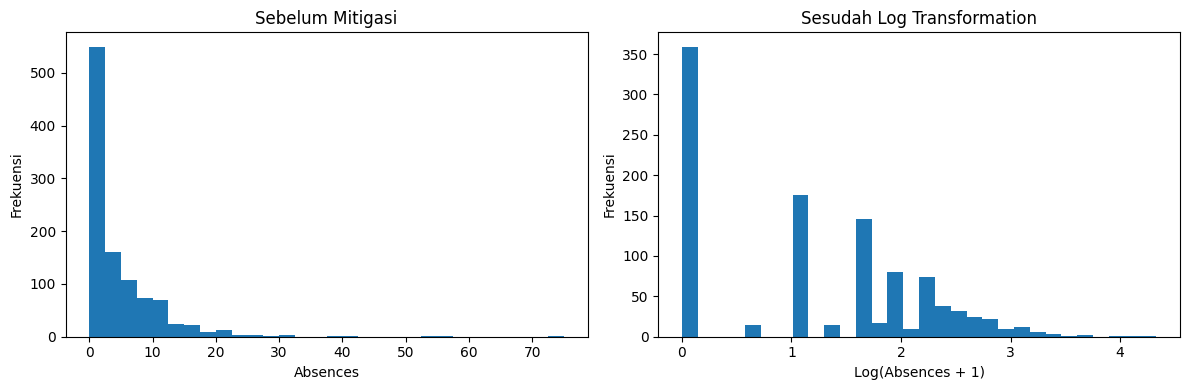

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sebelum mitigasi
axes[0].hist(df['absences'], bins=30)
axes[0].set_title('Sebelum Mitigasi')
axes[0].set_xlabel('Absences')
axes[0].set_ylabel('Frekuensi')

# Sesudah Log Transformation
axes[1].hist(absences_log, bins=30)
axes[1].set_title('Sesudah Log Transformation')
axes[1].set_xlabel('Log(Absences + 1)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# ==================================================
# NO. 3 - MISSING DATA
# ==================================================

In [19]:
# Mengecek jumlah missing value setiap kolom
missing = df.isnull().sum()

print("Jumlah Missing Value Setiap Kolom:")
print(missing[missing > 0])

Jumlah Missing Value Setiap Kolom:
Series([], dtype: int64)


Kesimpulan sementara:
Dataset sudah lengkap pada bagian nilai yang diperiksa, sehingga
metode imputasi seperti KNNImputer tidak perlu diterapkan pada
data asli.

# ==================================================
# NO. 4 - MULTIKOLINEARITAS
# ==================================================


In [20]:
# Mengambil kolom numerik
df_numerik = df.select_dtypes(include='number')

# Melihat korelasi antar fitur numerik
korelasi = df_numerik.corr()

print("Matriks Korelasi:")
print(korelasi)

Matriks Korelasi:
                 age      Medu      Fedu  traveltime  studytime  failures  \
age         1.000000 -0.130196 -0.138521    0.049216  -0.007870  0.282364   
Medu       -0.130196  1.000000  0.642063   -0.238181   0.090616 -0.187769   
Fedu       -0.138521  0.642063  1.000000   -0.196328   0.033458 -0.191390   
traveltime  0.049216 -0.238181 -0.196328    1.000000  -0.081328  0.087177   
studytime  -0.007870  0.090616  0.033458   -0.081328   1.000000 -0.152024   
failures    0.282364 -0.187769 -0.191390    0.087177  -0.152024  1.000000   
famrel      0.007162  0.015004  0.013066   -0.012578   0.012324 -0.053676   
freetime    0.002645  0.001054  0.002142   -0.007403  -0.094429  0.102679   
goout       0.118510  0.025614  0.030075    0.049740  -0.072941  0.074683   
Dalc        0.133453  0.001515 -0.000165    0.109423  -0.159665  0.116336   
Walc        0.098291 -0.029331  0.019524    0.084292  -0.229073  0.107432   
health     -0.029129 -0.013254  0.034288   -0.029002  -0.0

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Mengambil data numerik
X = df.select_dtypes(include='number').copy()

# Menghitung VIF setiap fitur
vif = pd.DataFrame()
vif["Fitur"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Urutkan dari VIF terbesar
vif = vif.sort_values(by="VIF", ascending=False)

print("=== HASIL VIF ===")
print(vif)

=== HASIL VIF ===
         Fitur       VIF
14          G2  8.028318
15          G3  6.133658
13          G1  3.997109
10        Walc  1.956582
1         Medu  1.802869
2         Fedu  1.748294
9         Dalc  1.709369
8        goout  1.356595
5     failures  1.314399
7     freetime  1.172660
0          age  1.149340
4    studytime  1.116543
3   traveltime  1.096201
12    absences  1.081590
6       famrel  1.068298
11      health  1.055737


In [26]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Ambil fitur numerik
X_vif = df.select_dtypes(include='number').copy()

# Standardisasi
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X_vif),
    columns=X_vif.columns
)

# Hitung VIF setelah mitigasi
vif_sesudah = pd.DataFrame()
vif_sesudah["Fitur"] = X_scaled.columns
vif_sesudah["VIF"] = [
    variance_inflation_factor(X_scaled.values, i)
    for i in range(X_scaled.shape[1])
]

vif_sesudah = vif_sesudah.sort_values(
    by="VIF",
    ascending=False
)

print("=== VIF SESUDAH MITIGASI ===")
print(vif_sesudah)

=== VIF SESUDAH MITIGASI ===
         Fitur       VIF
14          G2  8.028318
15          G3  6.133658
13          G1  3.997109
10        Walc  1.956582
1         Medu  1.802869
2         Fedu  1.748294
9         Dalc  1.709369
8        goout  1.356595
5     failures  1.314399
7     freetime  1.172660
0          age  1.149340
4    studytime  1.116543
3   traveltime  1.096201
12    absences  1.081590
6       famrel  1.068298
11      health  1.055737


In [28]:
# Mitigasi: menghilangkan fitur dengan VIF tertinggi
X_mitigasi = df.select_dtypes(include='number').drop(columns=['G2'])

# Hitung VIF ulang
vif_sesudah = pd.DataFrame()
vif_sesudah["Fitur"] = X_mitigasi.columns
vif_sesudah["VIF"] = [
    variance_inflation_factor(X_mitigasi.values, i)
    for i in range(X_mitigasi.shape[1])
]

vif_sesudah = vif_sesudah.sort_values(
    by="VIF",
    ascending=False
)

print("=== VIF SESUDAH ELIMINASI G2 ===")
print(vif_sesudah)

=== VIF SESUDAH ELIMINASI G2 ===
         Fitur       VIF
13          G1  3.061767
14          G3  2.996940
10        Walc  1.956570
1         Medu  1.801278
2         Fedu  1.748181
9         Dalc  1.707776
8        goout  1.355622
5     failures  1.314371
7     freetime  1.172139
0          age  1.148537
4    studytime  1.116496
3   traveltime  1.087436
12    absences  1.072216
6       famrel  1.068239
11      health  1.052954


Catatan:
Eliminasi G2 pada tahap mitigasi dilakukan pada matriks prediktor
(X_mitigasi) untuk menguji pengaruhnya terhadap multikolinearitas.
Kolom G2 pada dataset asli (df) tidak dihapus.

# ==================================================
# NO. 5 - Class Imbalance.
# ==================================================


In [30]:
print("=== DISTRIBUSI NILAI G3 ===")
print(df["G3"].value_counts().sort_index())

=== DISTRIBUSI NILAI G3 ===
G3
0      53
1       1
4       1
5       8
6      18
7      19
8      67
9      63
10    153
11    151
12    103
13    113
14     90
15     82
16     52
17     35
18     27
19      7
20      1
Name: count, dtype: int64


In [31]:
print("\n=== JUMLAH DATA ===")
print(len(df))


=== JUMLAH DATA ===
1044


=== HASIL PENGECEKAN NO. 5 ===

Jumlah data: 1044

Target G3 masih berupa nilai numerik (0–20), bukan kelas
klasifikasi.

Distribusi nilai G3:
Nilai 10 = 153 siswa
Nilai 11 = 151 siswa
Nilai 12 = 103 siswa
...
Nilai 1, 4, dan 20 = masing-masing 1 siswa.

Karena G3 merupakan nilai numerik dan belum ditentukan sebagai
kelas klasifikasi, perhitungan Imbalance Ratio belum dapat
diterapkan secara langsung.

# ==================================================
# NO. 6 - Bias Asumsi Linearitas
# ==================================================


In [32]:
from scipy import stats
import pandas as pd

# Fitur numerik
X_fitur = df.select_dtypes(include='number').drop(columns=['G3'])

# Target
y_target = df['G3']

# Pearson
pearson_scores = X_fitur.apply(
    lambda col: stats.pearsonr(col, y_target)[0]
).abs()

# Spearman
spearman_scores = X_fitur.apply(
    lambda col: stats.spearmanr(col, y_target)[0]
).abs()

# Gabungkan
komparasi = pd.DataFrame({
    "Pearson (Linear)": pearson_scores,
    "Spearman (Monotonik)": spearman_scores
})

print("=== PERBANDINGAN PEARSON VS SPEARMAN ===")
print(komparasi.sort_values(
    by="Pearson (Linear)",
    ascending=False
).round(4))

=== PERBANDINGAN PEARSON VS SPEARMAN ===
            Pearson (Linear)  Spearman (Monotonik)
G2                    0.9107                0.9523
G1                    0.8091                0.8840
failures              0.3831                0.4127
Medu                  0.2015                0.2383
studytime             0.1616                0.1898
Fedu                  0.1598                0.1900
Dalc                  0.1296                0.1719
age                   0.1253                0.1103
Walc                  0.1157                0.1493
traveltime            0.1026                0.1191
goout                 0.0979                0.1201
health                0.0801                0.0808
freetime              0.0649                0.0818
famrel                0.0545                0.0494
absences              0.0457                0.1090


In [33]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Gunakan fitur dan target yang sama seperti sebelumnya
X_fitur = df.select_dtypes(include='number').drop(columns=['G3'])
y_target = df['G3']

# Mutual Information untuk target numerik
mi_scores = pd.Series(
    mutual_info_regression(
        X_fitur,
        y_target,
        random_state=42
    ),
    index=X_fitur.columns
)

# Gabungkan ketiga metode
komparasi = pd.DataFrame({
    "Pearson (Linear)": pearson_scores,
    "Spearman (Monotonik)": spearman_scores,
    "Mutual Information": mi_scores
})

print("=== PERBANDINGAN SEBELUM DAN SESUDAH MITIGASI ===")
print(komparasi.sort_values(
    by="Mutual Information",
    ascending=False
).round(4))

=== PERBANDINGAN SEBELUM DAN SESUDAH MITIGASI ===
            Pearson (Linear)  Spearman (Monotonik)  Mutual Information
G2                    0.9107                0.9523              1.2566
G1                    0.8091                0.8840              0.7759
failures              0.3831                0.4127              0.1135
absences              0.0457                0.1090              0.0806
Walc                  0.1157                0.1493              0.0519
age                   0.1253                0.1103              0.0415
Dalc                  0.1296                0.1719              0.0300
Medu                  0.2015                0.2383              0.0292
traveltime            0.1026                0.1191              0.0257
studytime             0.1616                0.1898              0.0196
freetime              0.0649                0.0818              0.0122
goout                 0.0979                0.1201              0.0101
health                0.080

=== KESIMPULAN NO. 6 ===

Pada analisis awal, hubungan fitur dengan G3 dievaluasi menggunakan
korelasi Pearson. Hasil menunjukkan bahwa G2 dan G1 memiliki hubungan
yang kuat dengan G3, sedangkan beberapa fitur seperti absences memiliki
nilai korelasi Pearson yang sangat rendah.

Untuk mengurangi ketergantungan terhadap asumsi hubungan linear,
dilakukan perbandingan menggunakan Pearson, Spearman, dan Mutual
Information. Hasil menunjukkan bahwa beberapa fitur memiliki nilai
Spearman dan Mutual Information yang berbeda dari Pearson, seperti
absences yang memiliki Pearson 0.0457, Spearman 0.1090, dan Mutual
Information 0.0806.

Dengan demikian, penggunaan Pearson saja dapat memberikan gambaran
yang terbatas mengenai hubungan antara fitur dan target. Penggunaan
Spearman dan Mutual Information memberikan perspektif tambahan dalam
menilai hubungan fitur dengan G3.

# ==================================================
# NO. 7 - Unique ID / High Cardinality.
# ==================================================


In [35]:
print("=== UNIQUE VALUE SETIAP KOLOM ===")

for col in df.columns:
    jumlah_unik = df[col].nunique()
    rasio_unik = jumlah_unik / len(df)

    print(
        f"{col:15} | "
        f"unik = {jumlah_unik:4} | "
        f"Uniqueness Ratio = {rasio_unik:.3f}"
    )

=== UNIQUE VALUE SETIAP KOLOM ===
school          | unik =    2 | Uniqueness Ratio = 0.002
sex             | unik =    2 | Uniqueness Ratio = 0.002
age             | unik =    8 | Uniqueness Ratio = 0.008
address         | unik =    2 | Uniqueness Ratio = 0.002
famsize         | unik =    2 | Uniqueness Ratio = 0.002
Pstatus         | unik =    2 | Uniqueness Ratio = 0.002
Medu            | unik =    5 | Uniqueness Ratio = 0.005
Fedu            | unik =    5 | Uniqueness Ratio = 0.005
Mjob            | unik =    5 | Uniqueness Ratio = 0.005
Fjob            | unik =    5 | Uniqueness Ratio = 0.005
reason          | unik =    4 | Uniqueness Ratio = 0.004
guardian        | unik =    3 | Uniqueness Ratio = 0.003
traveltime      | unik =    4 | Uniqueness Ratio = 0.004
studytime       | unik =    4 | Uniqueness Ratio = 0.004
failures        | unik =    4 | Uniqueness Ratio = 0.004
schoolsup       | unik =    2 | Uniqueness Ratio = 0.002
famsup          | unik =    2 | Uniqueness Ratio = 0.0

=== KESIMPULAN NO. 7 ===

Berdasarkan pemeriksaan uniqueness ratio, tidak ditemukan fitur
identitas berkardinalitas tinggi pada dataset Student Performance.

Nilai uniqueness ratio tertinggi terdapat pada fitur absences,
yaitu 0.034, sedangkan fitur G1, G2, dan G3 masing-masing
memiliki uniqueness ratio di bawah 0.02.

Tidak terdapat fitur dengan uniqueness ratio mendekati 1.0,
sehingga tidak ditemukan kolom ID yang berpotensi menyebabkan
overfitting akibat identitas unik.

Dengan demikian, tidak diperlukan penghapusan fitur sebagai
mitigasi untuk masalah Unique ID / High Cardinality pada dataset ini.

# ==================================================
# NO. 8 - Masking Effect pada Deteksi Outlier
# ==================================================


In [37]:
from scipy import stats
import numpy as np
import pandas as pd

absences_sampel = df["absences"].dropna().copy()

# Z-Score klasik
z_scores = np.abs(stats.zscore(absences_sampel))

outliers_zscore = absences_sampel[z_scores > 3]

print("=== Z-SCORE KLASIK ===")
print(f"Jumlah outlier terdeteksi: {len(outliers_zscore)}")
print(outliers_zscore)

=== Z-SCORE KLASIK ===
Jumlah outlier terdeteksi: 14
40     25
74     54
103    26
183    56
198    24
205    28
276    75
280    30
307    38
315    40
545    24
592    32
607    30
651    26
Name: absences, dtype: int64


In [38]:
# Median dan MAD
med = np.median(absences_sampel)
mad = np.median(np.abs(absences_sampel - med))

# Modified Z-Score
modified_z = 0.6745 * np.abs(absences_sampel - med) / mad

outliers_modified = absences_sampel[modified_z > 3.5]

print("=== MODIFIED Z-SCORE ===")
print(f"Jumlah outlier terdeteksi: {len(outliers_modified)}")
print(outliers_modified)

=== MODIFIED Z-SCORE ===
Jumlah outlier terdeteksi: 83
18     16
25     14
29     16
40     25
44     14
       ..
760    14
792    18
800    16
808    21
813    13
Name: absences, Length: 83, dtype: int64


=== KESIMPULAN NO. 8 ===

Pada fitur absences, Z-Score klasik mendeteksi sebanyak 14 data
sebagai outlier, sedangkan Modified Z-Score mendeteksi sebanyak
83 data.

Perbedaan tersebut menunjukkan bahwa metode deteksi outlier
memberikan hasil yang berbeda ketika data memiliki distribusi
yang menceng dan terdapat nilai ekstrem. Modified Z-Score yang
menggunakan median dan MAD lebih resisten terhadap pengaruh
pencilan ekstrem dibandingkan Z-Score klasik.

Namun, data yang terdeteksi sebagai outlier tidak langsung
dihapus karena perlu ditinjau lebih lanjut apakah data tersebut
merupakan kesalahan atau masih merupakan nilai yang valid.

# ==================================================
# NO. 9 - Multimodality / Subpopulasi Tersembunyi.
# ==================================================


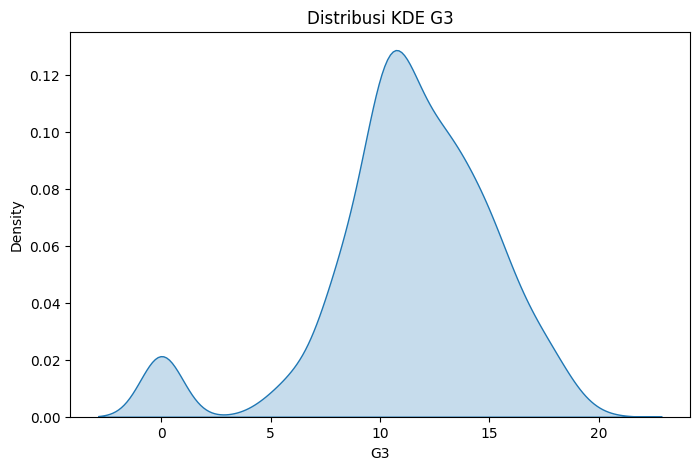

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x="G3",
    fill=True
)

plt.title("Distribusi KDE G3")
plt.xlabel("G3")
plt.ylabel("Density")
plt.show()

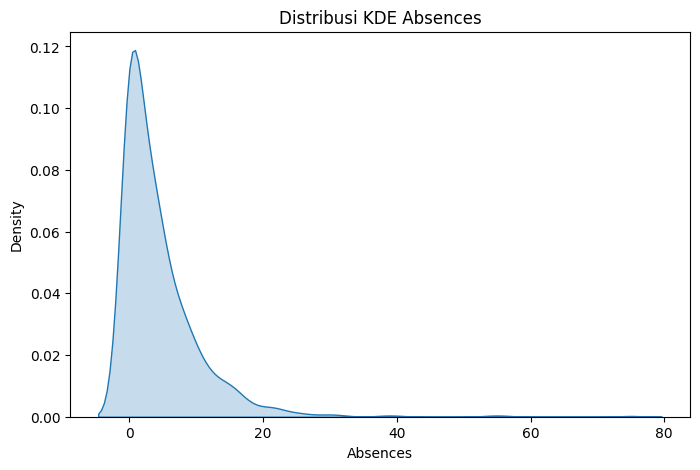

In [41]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x="absences",
    fill=True
)

plt.title("Distribusi KDE Absences")
plt.xlabel("Absences")
plt.ylabel("Density")
plt.show()

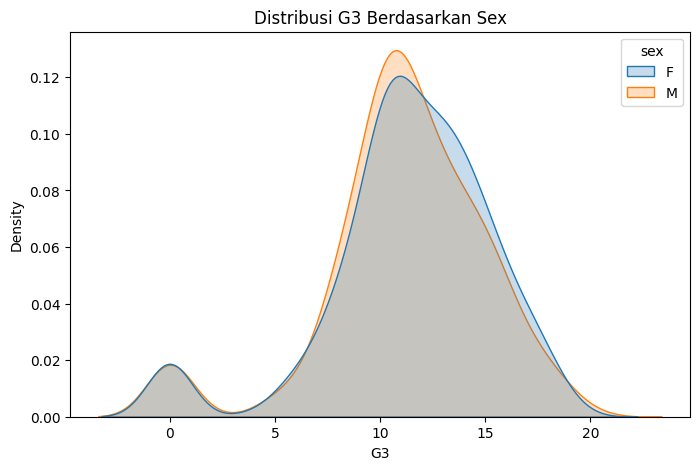

In [42]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x="G3",
    hue="sex",
    fill=True,
    common_norm=False
)

plt.title("Distribusi G3 Berdasarkan Sex")
plt.xlabel("G3")
plt.ylabel("Density")
plt.show()

In [43]:
from scipy import stats

# Mean G3 berdasarkan sex
mean_per_grup = df.groupby("sex")["G3"].mean()

# Uji perbedaan antara F dan M
t_stat, p_val = stats.ttest_ind(
    df[df["sex"] == "F"]["G3"].dropna(),
    df[df["sex"] == "M"]["G3"].dropna()
)

print("=== ANALISIS SUBPOPULASI G3 BERDASARKAN SEX ===")
print("\nMean G3 per kelompok:")
print(mean_per_grup.round(2))

print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.5f}")

=== ANALISIS SUBPOPULASI G3 BERDASARKAN SEX ===

Mean G3 per kelompok:
sex
F    11.45
M    11.20
Name: G3, dtype: float64

T-statistic: 1.0164
P-value: 0.30966


=== KESIMPULAN NO. 9 ===

Berdasarkan inspeksi KDE, distribusi G3 menunjukkan adanya
puncak kecil di sekitar nilai 0 dan puncak utama pada rentang
nilai 10–15, sehingga terdapat indikasi distribusi yang tidak
sepenuhnya unimodal.

Namun, ketika distribusi G3 didekomposisi berdasarkan variabel
sex, rata-rata G3 kelompok F adalah 11.45 dan kelompok M adalah
11.20. Hasil uji t menghasilkan p-value sebesar 0.30966,
sehingga tidak ditemukan perbedaan yang signifikan antara kedua
kelompok.

Dengan demikian, pada dataset ini belum terdapat bukti yang
cukup bahwa variabel sex membentuk subpopulasi G3 yang berbeda.

# ==================================================
# NO. 10 - Valid Outlier / True Positive Signal
# ==================================================


In [44]:
# Deteksi outlier absences menggunakan Tukey's Fences

q1 = df["absences"].quantile(0.25)
q3 = df["absences"].quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

mask_outlier = df["absences"] > upper_bound
outliers = df[mask_outlier]

print("=== DETEKSI OUTLIER ABSENCES ===")
print(f"Q1           : {q1:.2f}")
print(f"Q3           : {q3:.2f}")
print(f"IQR          : {iqr:.2f}")
print(f"Batas atas   : {upper_bound:.2f}")
print(f"Jumlah outlier: {len(outliers)}")

=== DETEKSI OUTLIER ABSENCES ===
Q1           : 0.00
Q3           : 6.00
IQR          : 6.00
Batas atas   : 15.00
Jumlah outlier: 54


In [45]:
mean_g3_outlier = outliers["G3"].mean()
mean_g3_populasi = df["G3"].mean()

print("\n=== DAMPAK OUTLIER TERHADAP TARGET G3 ===")
print(f"Rata-rata G3 kelompok outlier : {mean_g3_outlier:.2f}")
print(f"Rata-rata G3 seluruh populasi : {mean_g3_populasi:.2f}")


=== DAMPAK OUTLIER TERHADAP TARGET G3 ===
Rata-rata G3 kelompok outlier : 10.31
Rata-rata G3 seluruh populasi : 11.34


In [46]:
from scipy import stats

absences_stabil = stats.yeojohnson(df["absences"])[0]

print("\n=== SESUDAH MITIGASI ===")
print(f"Jumlah data sebelum : {len(df)}")
print(f"Jumlah data sesudah : {len(absences_stabil)}")
print("Transformasi Yeo-Johnson berhasil diterapkan.")


=== SESUDAH MITIGASI ===
Jumlah data sebelum : 1044
Jumlah data sesudah : 1044
Transformasi Yeo-Johnson berhasil diterapkan.


=== KESIMPULAN NO. 10 ===

Berdasarkan metode Tukey's Fences, fitur absences memiliki
batas atas sebesar 15 dan ditemukan sebanyak 54 data yang
tergolong sebagai outlier.

Rata-rata G3 pada kelompok outlier adalah 10.31, sedangkan
rata-rata G3 seluruh populasi adalah 11.34. Hal ini menunjukkan
bahwa kelompok dengan absences tinggi memiliki karakteristik
nilai G3 yang berbeda dari rata-rata populasi.

Namun, data outlier tidak langsung dihapus karena masih dapat
mengandung informasi yang relevan terhadap performa akademik.
Sebagai mitigasi, digunakan transformasi Yeo-Johnson untuk
menstabilkan nilai ekstrem tanpa menghilangkan data.

Jumlah data tetap 1044 sebelum dan sesudah transformasi,
sehingga seluruh data tetap dipertahankan.